## Synthetic data generation 

FSL-MRS needs to be installed in the environment (https://open.win.ox.ac.uk/pages/fsl/fsl_mrs/install.html)

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.io as sio

# Initialize variables
Tumor_Voxel = 0
Voxel_idx = 2

std_list = np.sqrt([0.000001, 0.00001, 0.0001, 0.001])
damping = [4, 8, 10, 12]

# Other constants and parameters
P = 1024
t = np.linspace(0, P, P) * 0.001
ppm = np.arange(-3.1583, 12.5583, 0.01535)

bIncludeLipid = 1
Niter_mc = 10
Niter = len(damping)
N_std = len(std_list)
Np = 228
savefile = 0 # ?? 

### Load metabolites basis set

In [2]:
from fsl_mrs.utils.preproc import nifti_mrs_proc as proc
import fsl_mrs.utils.mrs_io as mrs_io

basis = mrs_io.read_basis('PRESS_basis_WL_reduced')
basis.add_peak(ppm=1.3, amp = 10, name ='Lip', gamma = 2, sigma=2, conj = False) # Lipid peak

basis_array_FID = basis.original_basis_array/10000 
basis_array_spec = np.fft.fftshift(np.fft.fft(basis_array_FID, axis = 0), axes = 0) 

M = basis_array_spec.shape[1]
names = basis._names
M

22

### Visualize metabolites basis set

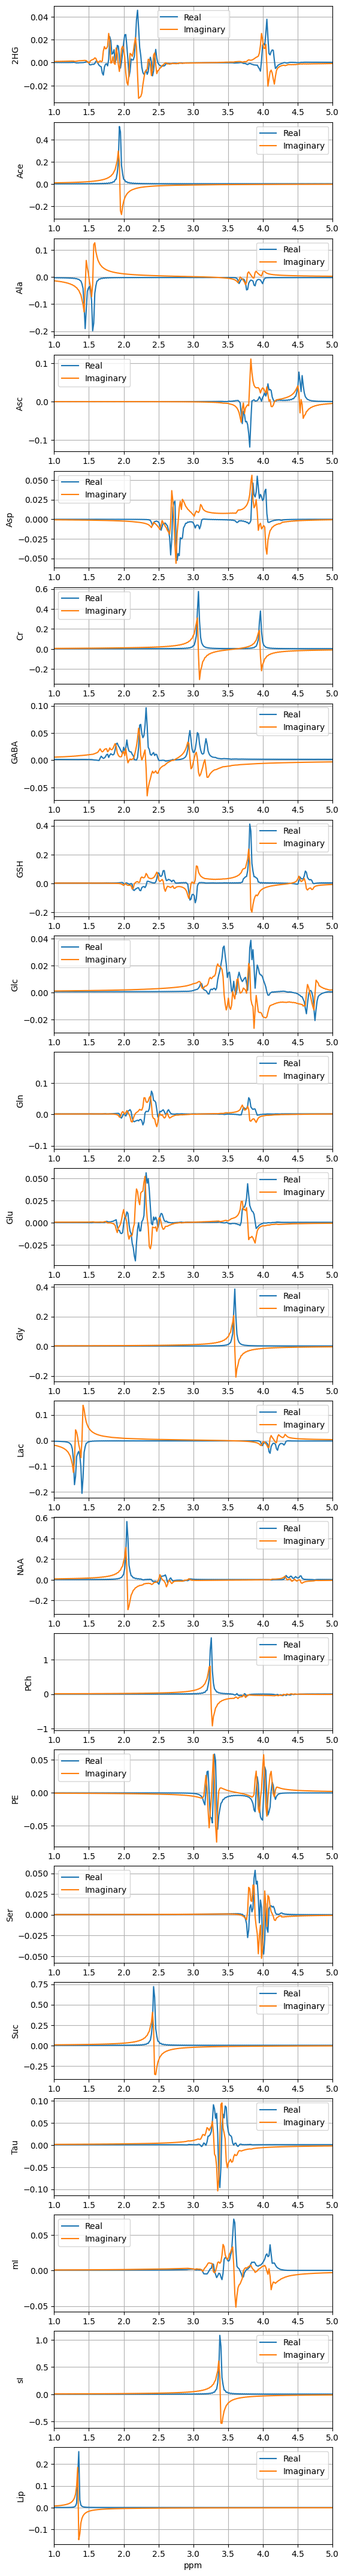

In [3]:
fig, axs = plt.subplots(np.shape(basis_array_spec)[1], 1, figsize=(6, 55))
for indx in range(np.shape(basis_array_spec)[1]):
    axs[indx].plot(ppm, np.real(basis_array_spec[:, indx]))
    axs[indx].plot(ppm, np.imag(basis_array_spec[:, indx]))
    axs[indx].set_xlim([1, 5])
    axs[indx].grid('On')
    axs[indx].set_ylabel(basis._names[indx])
    axs[indx].set_xlabel('ppm')
    axs[indx].legend(['Real', 'Imaginary'])

### Synthetic data generation - noise free + variable damping

Text(0.5, 1.0, 'Simulated spectra (Real part, different dampings)')

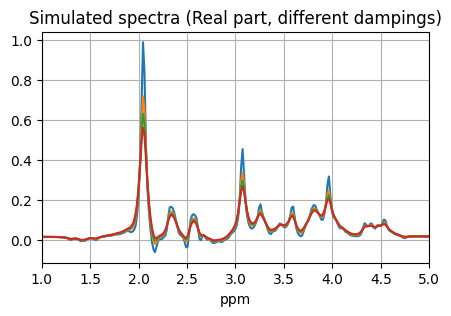

In [4]:
# Metabolite concentration
Metab_names = ['Ala', 'Asc', 'Asp', 'Cr', 'GABA', 'Glc', 'Gln', 'Glu', 'GSH', 'Gly', 'mI', 'Lac', 'NAA', 'PCh', 'PE', 'sI', 'Tau', 'Lip', 'Ace']

TV_conc_all = np.array([
    [8.24, 0, 0, 3.53, 0, 0, 18.82, 14.12, 0, 2.35, 3.53, 23.53, 2.35, 1.53, 0, 0, 0, 0, 2.35],
    [8.54, 0, 0, 3.66, 0, 0, 19.51, 14.63, 0, 2.44, 3.66, 24.39, 2.44, 1.59, 0, 0, 0, 0, 2.44],
    [8.54, 0, 0, 3.66, 0, 0, 19.51, 14.63, 0, 2.44, 3.66, 24.39, 2.44, 1.59, 0, 0, 0, 0, 2.44]
])

NV_conc_all = np.array([
    [0.74, 1.47, 2.94, 5.88, 1.47, 1.47, 3.68, 14.71, 1.47, 1.47, 8.82, 0.74, 17.65, 0.74, 2.21, 0.37, 2.21, 0],
    [0.6, 1.19, 2.38, 5.36, 1.19, 1.19, 3.57, 14.29, 1.19, 1.19, 8.33, 0.6, 11.9, 0.6, 1.79, 0.3, 1.79, 0],
    [0.6, 1.19, 2.38, 5.06, 1.19, 1.19, 2.98, 13.1, 1.19, 1.19, 11.9, 0.6, 14.29, 1.79, 1.79, 0.3, 1.79, 0]
])

# Voxel
if Tumor_Voxel == 1:
    TV_conc = TV_conc_all[Voxel_idx - 1, :]
else:
    NV_conc = NV_conc_all[Voxel_idx - 1, :]

# Create simulated spectra with no noise
Spectrum = np.zeros((P, Niter), dtype=complex)
A = np.zeros((M,))

if Tumor_Voxel == 1:
    for mm in range(len(TV_conc)):
        m_idx = names.index(Metab_names[mm])
        A[m_idx] = TV_conc[mm]
else:
    for mm in range(len(NV_conc)):
        m_idx = names.index(Metab_names[mm])
        A[m_idx] = NV_conc[mm]

for dp in range(Niter):
    for mm in range(len(A)):
        Metab_H = np.fft.fftshift(np.fft.fft(basis_array_FID[:, mm] * np.exp(-t * damping[dp])))
        Spectrum[:, dp] += A[mm] * Metab_H

coef_norm_vox = np.max(np.abs(Spectrum[239:500, :]), axis=0)
Spectrum /= np.max(coef_norm_vox)
A /= np.max(coef_norm_vox)

plt.figure(figsize=(5, 3))
plt.plot(ppm, np.real(Spectrum))
# plt.plot(ppm, np.imag(Spectrum))
plt.xlim([1, 5])
plt.grid('On')
plt.xlabel('ppm')
plt.title('Simulated spectra (Real part, different dampings)')

### Add variable levels of noise (gaussian)

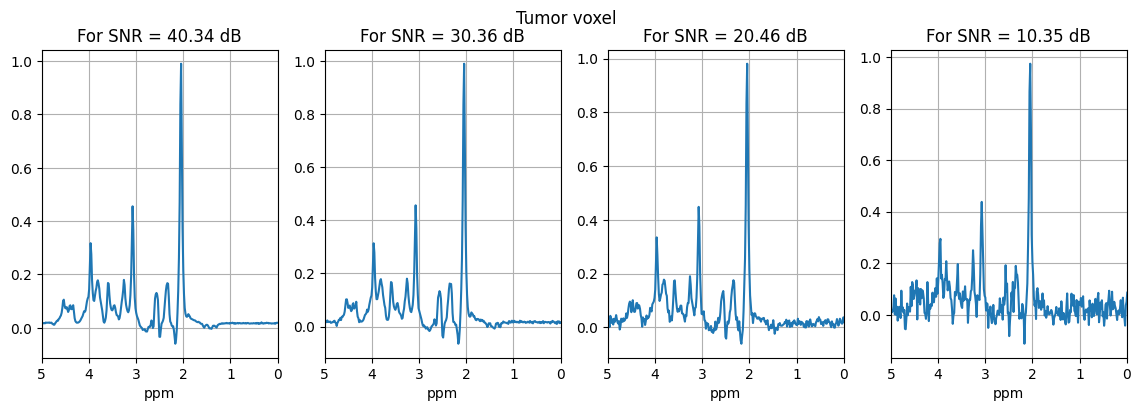

In [5]:
from mcmc import SNR

# Simulation spectres synthetique
S_sim_matrix = np.zeros((P, Niter, N_std, Niter_mc), dtype=complex)
A_matrix = np.zeros((M, Niter, N_std, Niter_mc))
SNR_matrix = np.zeros((Niter, N_std, Niter_mc))
CR_error_matrix = np.zeros((M, Niter, N_std, Niter_mc))


for iter in range(Niter):
    for std_index in range(N_std):
        std_dev = std_list[std_index]
        for iter_mc in range(Niter_mc):
            gaussian_noise_re = std_dev * np.random.randn(P)
            gaussian_noise_im = std_dev * np.random.randn(P)
            gaussian_noise = gaussian_noise_re + 1j * gaussian_noise_im
            Sim_spectra = Spectrum[:, iter] + gaussian_noise
            SNR_matrix[iter, std_index, iter_mc] = SNR((Sim_spectra[239:500]), (Spectrum[239:500, iter]))
            S_sim_matrix[:, iter, std_index, iter_mc] = Sim_spectra

SNR_sim = np.mean(SNR_matrix, axis=2)
SNR_mean = np.mean(SNR_sim, axis=0)
SNR_mean_all = np.mean(SNR_matrix, axis=2).T

# Plotting
fig, axs = plt.subplots(1, N_std, figsize=(14, 4), sharex=True)

for std_i in range(N_std):
    axs[std_i].plot(ppm, np.real(S_sim_matrix[:, 0, std_i, 0]))
    axs[std_i].set_xlim([0, 5])
    axs[std_i].grid(True)
    axs[std_i].set_xlabel('ppm')
    axs[std_i].set_title(f'For SNR = {SNR_mean[std_i]:.2f} dB')

plt.gca().invert_xaxis()  # Reverse x-axis
plt.suptitle('Tumor voxel')
plt.show()


### Save as nifti-mrs file if needed

In [ ]:
from nifti_mrs.create_nmrs import gen_nifti_mrs

MRS_nifti_out = 'MRSI_output.nii'

Spec_sim = np.transpose(np.reshape(S_sim_matrix, (np.shape(S_sim_matrix)[0], np.shape(S_sim_matrix)[1], np.shape(S_sim_matrix)[2], np.shape(S_sim_matrix)[3])), (1, 2, 3, 0))
FID_sim = np.fft.ifft(np.fft.ifftshift(Spec_sim, axes=(3, 3, 3)))

affine = np.zeros((4, 4), dtype=float)
affine[0,0] = 1
affine[1,1] = 1
affine[2,2] = 1

DwellTime = 1000.0
MRFrequency = 63.648821

gen_nifti_mrs(FID_sim,
              float(DwellTime)/1e6,
              float(MRFrequency),
              '1H',
              affine).save(MRS_nifti_out)

final_data = mrs_io.read_FID(MRS_nifti_out)
mrsi = final_data.mrs(basis =  basis)
(n_i, n_j, n_k) = np.shape(final_data)[0:3]